### Loading CSV and Preparing Token Corpora

This cell loads the CSV file, converts the token columns from string format into Python lists, and builds the partial and full corpora. It also prints the corpus sizes and shows an example row for basic validation.

In [ ]:
%reset -f

In [2]:
import ast
import pandas as pd

df = pd.read_csv("step_2.csv")
print("Loaded step_5.csv successfully!")

df["tokens_partial"] = df["tokens_partial"].apply(ast.literal_eval)
df["tokens_full"]    = df["tokens_full"].apply(ast.literal_eval)

corpus_partial = df["tokens_partial"].tolist()
corpus_full    = df["tokens_full"].tolist()

print("Corpus ready (from CSV tokens):")
print(" - Partial corpus size:", len(corpus_partial))
print(" - Full corpus size:",    len(corpus_full))

del ast
del df
del pd


Corpus ready (from CSV tokens):
 - Partial corpus size: 9999
 - Full corpus size: 9999


### Computing Statistics for the Full Corpus

This cell flattens all tokens from the full corpus and calculates key statistics, including the total number of documents, total tokens, vocabulary size, and average document length. It also builds a frequency counter and prints the most common words in the corpus.


In [3]:
from collections import Counter

def filter_corpus(corpus, vocab):
    vocab = set(vocab)
    return [[w for w in doc if w in vocab] for doc in corpus]


# ===== 1. Basic vocab stats for full & partial =====

# Flatten tokens
all_tokens_full = [tok for doc in corpus_full for tok in doc]
all_tokens_partial = [tok for doc in corpus_partial for tok in doc]

# Vocab sets
vocab_full = set(all_tokens_full)
vocab_size_full = len(vocab_full)

vocab_partial = set(all_tokens_partial)
vocab_size_partial = len(vocab_partial)

print("Size of vocabulary of the full clean:", vocab_size_full)
print("Size of vocabulary of the partial clean:", vocab_size_partial)

# Frequency distribution for FULL corpus
freq_full = Counter(all_tokens_full)
print("Top frequent words in full corpus:")
print(freq_full.most_common(10))



Size of vocabulary of the full clean: 23409
Size of vocabulary of the partial clean: 29450
Top frequent words in full corpus:
[('experience', 11491), ('recommend', 9852), ('do', 7936), ('overall', 7481), ('product', 7445), ('look', 7404), ('use', 6930), ('make', 5893), ('like', 5618), ('try', 4535)]


### Filtering the Corpus to the Top 15000 Words

This cell selects the 15,000 most frequent words in the full corpus and filters all documents so they contain only tokens from this reduced vocabulary. It then prints the size of the selected vocabulary and the filtered corpus.

In [4]:
# ===== 2. Build top-15k context vocab from FULL =====
TOP_K = 15000
top_15k_words = [w for w, _ in freq_full.most_common(TOP_K)]
context2idx = {w: i for i, w in enumerate(top_15k_words)}

print("Size of context vocabulary (top 15k from full):", len(top_15k_words))

# (Optional) create a filtered version of the full corpus that only uses top-15k words
corpus_full_top15k = filter_corpus(corpus_full, top_15k_words)

# Just to see how many unique words remain after filtering (optional)
all_tokens_full_top15k = [tok for doc in corpus_full_top15k for tok in doc]
vocab_full_top15k = set(all_tokens_full_top15k)
vocab_size_full_top15k = len(vocab_full_top15k)

print("Size of vocabulary of the full clean (only top15k kept):", vocab_size_full_top15k)

Size of context vocabulary (top 15k from full): 15000
Size of vocabulary of the full clean (only top15k kept): 15000


### Building the Co-occurrence Matrix

This cell prepares the vocabulary index and defines a function that constructs a sparse co-occurrence matrix using a sliding window. Only words within the top 20,000 vocabulary are included, and co-occurrence counts are stored in a sparse matrix for efficiency.


In [5]:
from scipy.sparse import lil_matrix, save_npz
import numpy as np

def build_cooccurrence_matrix(corpus, row_word2idx, context2idx,
                              window_size=2, corpus_name="cooc"):
    V_rows = len(row_word2idx)
    V_cols = len(context2idx)

    cooc = lil_matrix((V_rows, V_cols), dtype=np.int32)

    for doc in corpus:
        n = len(doc)
        for i, w in enumerate(doc):
            if w not in row_word2idx:
                continue
            w_idx = row_word2idx[w]

            start = max(0, i - window_size)
            end   = min(n, i + window_size + 1)

            for j in range(start, end):
                if j == i:
                    continue

                c = doc[j]
                if c not in context2idx:
                    continue

                c_idx = context2idx[c]
                cooc[w_idx, c_idx] += 1

    cooc = cooc.tocsr()

    save_path = f"coco/{corpus_name}_window{window_size}.npz"
    save_npz(save_path, cooc)
    print(f"Co-occurrence matrix saved to: {save_path}  | shape={cooc.shape}")

    return cooc

### Generating Co-occurrence Matrices for Selected Window Sizes

This cell iterates over the chosen window sizes and builds co-occurrence matrices for the filtered corpus. For each window size, it reports the matrix shape, number of non-zero entries, and sparsity density. All matrices are stored in a structured dictionary for later use.

In [6]:
from collections import Counter

window_sizes = [2, 5, 10]

corpora = {
    "clean": corpus_full_top15k,  # full corpus but filtered to top-15k
    "partial": corpus_partial,
    "full": corpus_full,
}

for corp_name, corpus in corpora.items():
    print(f"\n===============================")
    print(f"Building matrices for corpus: {corp_name}")
    print("===============================")

    # Build row vocabulary (all words in this corpus)
    all_tokens = [tok for doc in corpus for tok in doc]
    freq = Counter(all_tokens)

    vocab_list = [w for w, _ in freq.most_common()]
    row_word2idx = {w: i for i, w in enumerate(vocab_list)}

    print("Number of words in this corpus (rows vocab):", len(vocab_list))

    for ws in window_sizes:
        print(f"\n--- Window size = {ws} ---")
        cooc = build_cooccurrence_matrix(
            corpus,
            row_word2idx,
            context2idx,
            window_size=ws,
            corpus_name=f"{corp_name}_rowsAll_cols15k"
        )


Building matrices for corpus: clean
Number of words in this corpus (rows vocab): 15000

--- Window size = 2 ---
Co-occurrence matrix saved to: coco/clean_rowsAll_cols15k_window2.npz  | shape=(15000, 15000)

--- Window size = 5 ---
Co-occurrence matrix saved to: coco/clean_rowsAll_cols15k_window5.npz  | shape=(15000, 15000)

--- Window size = 10 ---
Co-occurrence matrix saved to: coco/clean_rowsAll_cols15k_window10.npz  | shape=(15000, 15000)

Building matrices for corpus: partial
Number of words in this corpus (rows vocab): 29450

--- Window size = 2 ---
Co-occurrence matrix saved to: coco/partial_rowsAll_cols15k_window2.npz  | shape=(29450, 15000)

--- Window size = 5 ---
Co-occurrence matrix saved to: coco/partial_rowsAll_cols15k_window5.npz  | shape=(29450, 15000)

--- Window size = 10 ---
Co-occurrence matrix saved to: coco/partial_rowsAll_cols15k_window10.npz  | shape=(29450, 15000)

Building matrices for corpus: full
Number of words in this corpus (rows vocab): 23409

--- Window

##  Loading and Inspecting Stored Co-occurrence Matrices

This section loads the previously generated co-occurrence matrices for each corpus version (`clean`, `partial`, `full`) and for each selected window size (`2`, `5`, `10`).  
For every matrix, it prints:

- **Matrix shape** (number of rows × number of columns)  
- **Number of non-zero entries** (how many word–context pairs actually co-occur)  
- **Matrix density** — the percentage of cells that contain a non-zero value  

This allows us to examine how corpus type and window size affect sparsity and co-occurrence structure.


### Inspecting Co-occurrence Matrices
Load each saved co-occurrence matrix (for all corpora and window sizes) and print its shape, non-zero count, and density.

In [7]:
from scipy.sparse import load_npz

for corpus_name in corpora.keys():
    for window_size in window_sizes:

        print(f"\n=== Corpus: {corpus_name}, Window size = {window_size} ===")

        path = f"coco/{corpus_name}_rowsAll_cols15k_window{window_size}.npz"
        print("Loading:", path)

        cooc = load_npz(path)

        print("Shape:", cooc.shape)
        print("Non-zero cells:", cooc.nnz)

        density = cooc.nnz / (cooc.shape[0] * cooc.shape[1])
        print("Density:", round(density, 8))



=== Corpus: clean, Window size = 2 ===
Loading: coco/clean_rowsAll_cols15k_window2.npz
Shape: (15000, 15000)
Non-zero cells: 1371335
Density: 0.00609482

=== Corpus: clean, Window size = 5 ===
Loading: coco/clean_rowsAll_cols15k_window5.npz
Shape: (15000, 15000)
Non-zero cells: 2926767
Density: 0.01300785

=== Corpus: clean, Window size = 10 ===
Loading: coco/clean_rowsAll_cols15k_window10.npz
Shape: (15000, 15000)
Non-zero cells: 4728543
Density: 0.02101575

=== Corpus: partial, Window size = 2 ===
Loading: coco/partial_rowsAll_cols15k_window2.npz
Shape: (29450, 15000)
Non-zero cells: 1182524
Density: 0.00267691

=== Corpus: partial, Window size = 5 ===
Loading: coco/partial_rowsAll_cols15k_window5.npz
Shape: (29450, 15000)
Non-zero cells: 2655894
Density: 0.00601221

=== Corpus: partial, Window size = 10 ===
Loading: coco/partial_rowsAll_cols15k_window10.npz
Shape: (29450, 15000)
Non-zero cells: 4457794
Density: 0.01009121

=== Corpus: full, Window size = 2 ===
Loading: coco/full_ro

### Co-occurrence Neighbors Function
Define a helper function that computes the top-k nearest neighbors of a word using cosine similarity over raw co-occurrence vectors.


In [8]:
import numpy as np
from numpy.linalg import norm

def top_neighbors_cooc(word, cooc_matrix, word2idx, vocab_list, top_k=10):
    """
    Find top-k nearest neighbors for `word` using the raw co-occurrence matrix.
    cooc_matrix is expected to be a sparse CSR matrix (rows = words).
    """
    if word not in word2idx:
        print(f"'{word}' not in vocabulary")
        return []

    idx = word2idx[word]

    # Get vector of the target word (row from cooc)
    w_vec = cooc_matrix[idx].toarray().ravel()

    # Compute cosine similarity with all rows
    all_vecs = cooc_matrix.toarray()

    sims = all_vecs @ w_vec / (norm(all_vecs, axis=1) * norm(w_vec) + 1e-10)

    # Ignore the word itself
    sims[idx] = -1

    # Get top-k indices
    top_idx = np.argsort(sims)[::-1][:top_k]

    neighbors = [(vocab_list[i], float(sims[i])) for i in top_idx]
    return neighbors

### Raw Co-occurrence Neighbors (All Corpora & Windows)
For each corpus and window size, rebuild the row vocabulary, load the corresponding co-occurrence matrix, and print the top neighbors for selected target words.


In [9]:
target_words = ["good", "bad", "product", "quality", "service", "excellent", "terrible"]
for corp_name, corpus in corpora.items():
    print("\n===================================")
    print(f"Corpus: {corp_name}")
    print("===================================")

    all_tokens = [tok for doc in corpus for tok in doc]
    freq = Counter(all_tokens)
    vocab_list = [w for w, _ in freq.most_common()]
    word2idx = {w: i for i, w in enumerate(vocab_list)}

    print("Row vocab size:", len(vocab_list))

    for w in window_sizes:
        cooc_path = f"coco/{corp_name}_rowsAll_cols15k_window{w}.npz"
        print(f"\n--- Window size = {w} ---")
        print("Loading:", cooc_path)

        cooc = load_npz(cooc_path)
        print("Cooc shape:", cooc.shape)

        for word in target_words:
            print(f"\nCo-occurrence neighbors of '{word}' (corpus={corp_name}, window={w}):")
            print(top_neighbors_cooc(word, cooc, word2idx, vocab_list, top_k=10))


Corpus: clean
Row vocab size: 15000

--- Window size = 2 ---
Loading: coco/clean_rowsAll_cols15k_window2.npz
Cooc shape: (15000, 15000)

Co-occurrence neighbors of 'good' (corpus=clean, window=2):
[('decent', 0.7682088364197395), ('great', 0.7579884364360304), ('best', 0.6792013483737318), ('want', 0.6760722866309689), ('improve', 0.630005388761873), ('topnotch', 0.6276974186041252), ('basic', 0.6145502294568768), ('like', 0.604115901120312), ('simply', 0.5928675244592898), ('solid', 0.5905229726599156)]

Co-occurrence neighbors of 'bad' (corpus=clean, window=2):
[('hard', 0.6708306684103388), ('difficult', 0.5475412822505997), ('chore', 0.5383327668295504), ('perfect', 0.5326662811714964), ('sure', 0.5253031129605257), ('impossible', 0.5240872635840714), ('rest', 0.5162922627314451), ('shortcoming', 0.5155339526518012), ('breeze', 0.4988001931804801), ('ideal', 0.49308099642374664)]

Co-occurrence neighbors of 'product' (corpus=clean, window=2):
[('way', 0.8028950160468128), ('certai

### Selecting Main Co-occurrence Matrix
Load the clean corpus (window=5) co-occurrence matrix and rebuild its row vocabulary for further analysis.


In [10]:
target_corpus = "clean"
target_window = 5

cooc_path = f"coco/{target_corpus}_rowsAll_cols15k_window{target_window}.npz"
cooc = load_npz(cooc_path)

corpus_clean = corpus_full_top15k

all_tokens_clean = [tok for doc in corpus_clean for tok in doc]
freq_clean = Counter(all_tokens_clean)

vocab_list = [w for w, _ in freq_clean.most_common()]
word2idx = {w: i for i, w in enumerate(vocab_list)}

### Defining the PPMI Computation Function

This cell defines a function that converts a raw co-occurrence matrix into a Positive Pointwise Mutual Information (PPMI) matrix. It computes PMI values only for non-zero co-occurrences, applies smoothing to avoid division or log errors, and replaces all negative PMI values with zero. The result is returned as a sparse CSR matrix suitable for downstream embedding methods.

In [11]:
from scipy.sparse import coo_matrix, csr_matrix

def compute_ppmi(cooc_csr: csr_matrix) -> csr_matrix:

    cooc_csr = cooc_csr.tocsr().astype(np.float32)

    total_count = cooc_csr.sum()
    if total_count == 0:
        return cooc_csr.copy()

    row_sums = np.array(cooc_csr.sum(axis=1)).ravel().astype(np.float32)
    col_sums = np.array(cooc_csr.sum(axis=0)).ravel().astype(np.float32)

    cooc_coo = cooc_csr.tocoo()

    data = cooc_coo.data.astype(np.float32, copy=False)

    p_xy = data / float(total_count)

    p_x = row_sums[cooc_coo.row] / float(total_count)
    p_y = col_sums[cooc_coo.col] / float(total_count)

    eps = np.float32(1e-10)

    denom = p_x * p_y + eps
    ratio = (p_xy + eps) / denom

    pmi = np.log(ratio, dtype=np.float32)

    pmi[pmi < 0] = 0.0

    ppmi_coo = coo_matrix(
        (pmi, (cooc_coo.row, cooc_coo.col)),
        shape=cooc_csr.shape
    )

    return ppmi_coo.tocsr()

### Computing the PPMI Matrix

This cell selects the co-occurrence matrix for the chosen corpus and window size, applies the PPMI transformation, and reports the resulting matrix dimensions and number of non-zero entries. The computed PPMI matrix is stored for later use.


In [12]:
# Load the correct co-occurrence matrix (rowsAll + cols15k)
cooc_path = f"coco/{target_corpus}_rowsAll_cols15k_window{target_window}.npz"
print("Loading:", cooc_path)

cooc_main = load_npz(cooc_path)

ppmi = compute_ppmi(cooc_main)
print("PPMI shape:", ppmi.shape)
print("PPMI non-zero cells:", ppmi.nnz)


Loading: coco/clean_rowsAll_cols15k_window5.npz
PPMI shape: (15000, 15000)
PPMI non-zero cells: 2926767


### Retrieving Top Neighbors Using PPMI

This cell defines a function that returns the most strongly associated words for a given target word based on the PPMI matrix. It checks whether the word exists in the vocabulary, extracts its PPMI row, sorts the values in descending order, and returns the top scoring neighbors along with their PPMI scores.


In [13]:
def top_neighbors_ppmi(word, ppmi, word2idx, vocab_list, top_k=10):

    if word not in word2idx:
        print(f"'{word}' not in vocabulary")
        return []

    idx = word2idx[word]

    row = ppmi.getrow(idx)

    cols = row.indices
    values = row.data

    if values.size == 0:
        return []

    order = np.argsort(values)[::-1][:top_k]

    neighbors = [
        (vocab_list[cols[i]], float(values[i]))
        for i in order
    ]

    return neighbors


### Listing PPMI-Based Nearest Neighbors

This cell evaluates the PPMI similarity for a set of target words and prints their top neighbors. It helps inspect how well the PPMI representation captures semantic relationships between words.


In [14]:
top_k = 10

for word in target_words:
    neighbors = top_neighbors_ppmi(word, ppmi, word2idx, vocab_list, top_k=10)
    print(f"\nPPMI neighbors of '{word}' (corpus top 15k, window=5):")
    print(neighbors)



PPMI neighbors of 'good' (corpus top 15k, window=5):
[('conscience', 4.460561275482178), ('capstone', 4.449470520019531), ('cluckin', 4.449470520019531), ('broom', 4.233044624328613), ('aircon2000', 4.169632434844971), ('fromages', 4.033299446105957), ('growtopia', 4.033299446105957), ('trendystylescom', 4.033299446105957), ('writes', 4.033299446105957), ('contribution', 3.9715240001678467)]

PPMI neighbors of 'bad' (corpus top 15k, window=5):
[('enemy', 3.498807430267334), ('omen', 3.479417324066162), ('biohazard', 3.4732871055603027), ('colic', 3.4732871055603027), ('unconcerned', 3.4732871055603027), ('periodically', 3.4732871055603027), ('unbothered', 3.4732871055603027), ('karaoke', 3.4732871055603027), ('interacts', 3.4732871055603027), ('whirl', 3.191800355911255)]

PPMI neighbors of 'product' (corpus top 15k, window=5):
[('male', 2.856313705444336), ('underperforms', 2.8052473068237305), ('winning', 2.8052473068237305), ('odour', 2.8052473068237305), ('shelflife', 2.6861584186

### Performing SVD to Generate Word Embeddings

This cell applies Truncated SVD to the PPMI matrix in order to produce dense word embeddings. For each corpus and window size, it fits an SVD model with the specified dimensionality, prints the resulting vector shape, and the trained model for later analysis.


In [15]:
from sklearn.decomposition import TruncatedSVD

n_components = 300

svd = TruncatedSVD(n_components=n_components, random_state=42)
word_vecs = svd.fit_transform(ppmi).astype(np.float32)

print("Word vectors shape:", word_vecs.shape)  # (num_words, 300)

Word vectors shape: (15000, 300)


### Visualizing SVD Embeddings
Use PCA to project selected words from the SVD embedding space into 2D and visualize semantic clustering.


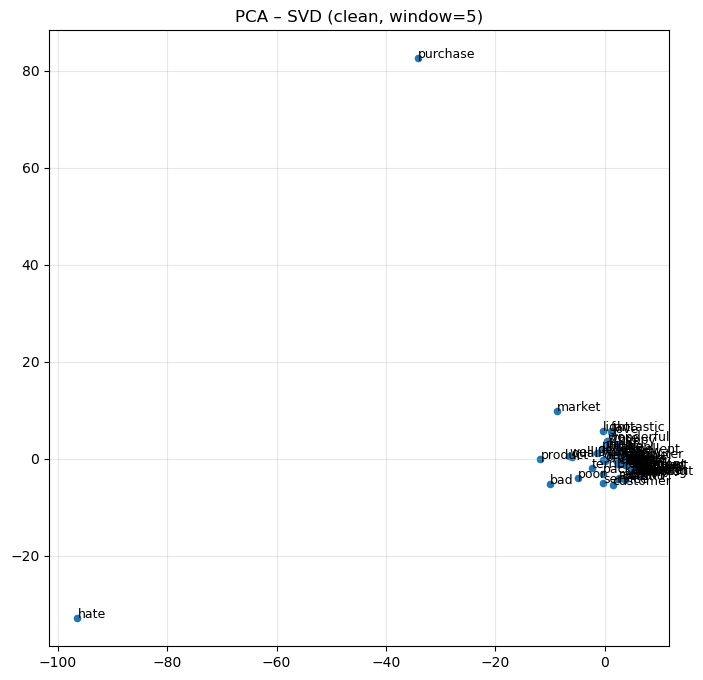

In [16]:
corpus_name = "clean"
window = 5

words = [
    # Sentiment (positive)
    "good", "great", "excellent", "wonderful", "superb",
    "fantastic", "love", "nice", "happy",

    # Sentiment (negative)
    "bad", "terrible", "horrible", "awful", "poor", "hate", "angry", "upset",

    # Product-related
    "product", "quality", "price", "service", "order", "delivery",
    "package", "shipping", "return", "refund",

    # Household
    "bath", "shower", "kitchen", "bed", "sofa", "chair",
    "table", "light", "towel", "soap",

    # Technology
    "ai", "assistant", "computer", "internet", "online",
    "device", "screen", "camera", "battery", "charger",
    "student",

    # Shopping
    "market", "store", "purchase", "buy", "sell",
    "customer", "review", "discount", "cart",

    # Misc
    "well", "super", "clean", "dirty", "water", "food"
]

vecs = []
labels = []

for w in words:
    if w in word2idx:
        vecs.append(word_vecs[word2idx[w]])
        labels.append(w)

vecs = np.array(vecs)

# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(vecs)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
plt.scatter(reduced[:,0], reduced[:,1], s=20)

for word, (x, y) in zip(labels, reduced):
    plt.text(x+0.02, y+0.02, word, fontsize=9)

plt.title(f"PCA – SVD (clean, window={window})")
plt.grid(True, alpha=0.3)
plt.show()


### SVD Neighbors Function
Define a function that returns the top-k most similar words using cosine similarity over SVD embeddings.


In [17]:
def top_neighbors_svd(word, word_vecs, word2idx, vocab_list, top_k=10):
    if word not in word2idx:
        print(f"'{word}' not in vocabulary")
        return []

    idx = word2idx[word]
    w_vec = word_vecs[idx]  # get the vector of the target word

    # compute cosine similarity with all vectors
    sims = word_vecs @ w_vec / (
        np.linalg.norm(word_vecs, axis=1) * np.linalg.norm(w_vec) + 1e-10
    )

    # ignore the word itself
    sims[idx] = -1

    # top k indices
    top_idx = np.argsort(sims)[::-1][:top_k]

    # map back to words
    neighbors = [(vocab_list[i], float(sims[i])) for i in top_idx]

    return neighbors

### SVD Nearest Neighbors
Print the top semantic neighbors of key words using SVD embeddings.


In [18]:
print(f"=== SVD neighbors of 'good' (corpus={target_corpus}, window={target_window}) ===")
print(top_neighbors_svd("good", word_vecs, word2idx, vocab_list, top_k=10))

print(f"\n=== SVD neighbors of 'bad' (corpus={target_corpus}, window={target_window}) ===")
print(top_neighbors_svd("bad", word_vecs, word2idx, vocab_list, top_k=10))

print(f"\n=== SVD neighbors of 'product' (corpus={target_corpus}, window={target_window}) ===")
print(top_neighbors_svd("product", word_vecs, word2idx, vocab_list, top_k=10))


=== SVD neighbors of 'good' (corpus=clean, window=5) ===
[('just', 0.56117182970047), ('great', 0.5557446479797363), ('decent', 0.5435723662376404), ('want', 0.5311518907546997), ('thing', 0.5284066796302795), ('value', 0.5143327713012695), ('special', 0.5034432411193848), ('okay', 0.4996859133243561), ('average', 0.4969070851802826), ('appreciate', 0.4936109781265259)]

=== SVD neighbors of 'bad' (corpus=clean, window=5) ===
[('matter', 0.726320743560791), ('enemy', 0.7091568112373352), ('make', 0.5789239406585693), ('let', 0.5582176446914673), ('leave', 0.49089762568473816), ('just', 0.4838751256465912), ('time', 0.4823097586631775), ('get', 0.4575100839138031), ('try', 0.443713903427124), ('take', 0.44267308712005615)]

=== SVD neighbors of 'product' (corpus=clean, window=5) ===
[('recommend', 0.671751856803894), ('experience', 0.6530638337135315), ('overall', 0.600365936756134), ('use', 0.5886353254318237), ('do', 0.5567026734352112), ('quality', 0.5468998551368713), ('unfortunatel

In [19]:
!pip install gensim

### Training Word2Vec
Train a Skip-gram Word2Vec model (100d, window=5) on the filtered corpus.


In [ ]:
from gensim.models import Word2Vec

w2v_window = 5
w2v_dim = 100
min_count = 5
sg = 1

w2v_model = Word2Vec(
    sentences=corpus_full_top15k,
    vector_size=w2v_dim,
    window=w2v_window,
    min_count=5,
    workers=4,
    sg=sg,
    epochs=10,
)


In [21]:
target_words = ["good", "bad", "product", "quality", "service", "excellent", "terrible"]

for word in target_words:
    if word in w2v_model.wv:
        print(f"\nClosest words to '{word}' (Word2Vec):")
        for neighbor, sim in w2v_model.wv.most_similar(word, topn=10):
            print(f"  {neighbor:15s} {sim:.3f}")
    else:
        print(f"'{word}' not in Word2Vec vocabulary")


Closest words to 'good' (Word2Vec):
  great           0.615
  decent          0.614
  whisky          0.593
  well            0.592
  best            0.586
  activesprings   0.576
  excites         0.550
  inoffensive     0.549
  fundamentally   0.547
  solidly         0.534

Closest words to 'bad' (Word2Vec):
  matter          0.619
  wrong           0.563
  terrible        0.560
  exasperate      0.544
  horrible        0.541
  hack            0.537
  mortify         0.532
  incompetent     0.531
  argue           0.527
  misshapen       0.526

Closest words to 'product' (Word2Vec):
  optiprotein     0.673
  quickstick      0.654
  ez              0.653
  kitchengenie    0.643
  modicum         0.643
  pantryfresh     0.638
  freshstart      0.632
  babygenius      0.630
  asks            0.626
  smartpack       0.625

Closest words to 'quality' (Word2Vec):
  subpar          0.607
  commendable     0.597
  shoddy          0.587
  affordability   0.562
  severely        0.561
  highe

### Visualizing Word2Vec Embeddings
Use PCA to project Word2Vec vectors into 2D and visualize semantic groupings.


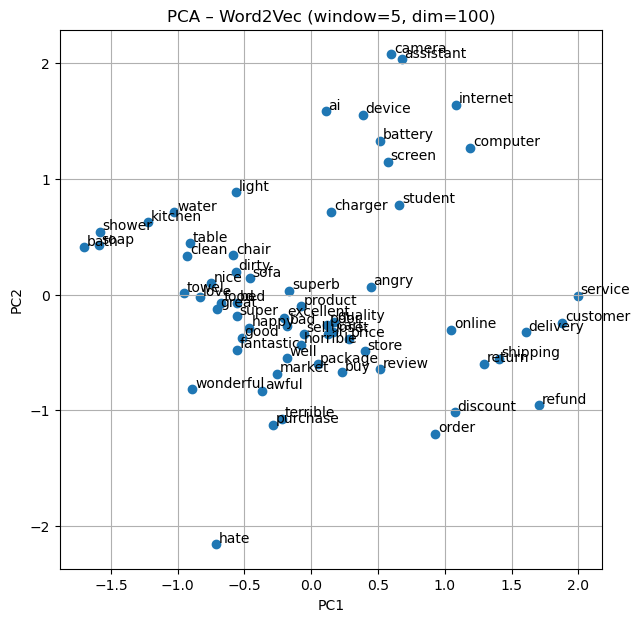

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np


vecs = np.array([w2v_model.wv[w] for w in words])

# PCA إلى 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(vecs)

# الرسم
plt.figure(figsize=(7, 7))
plt.scatter(reduced[:, 0], reduced[:, 1])

for w, (x, y) in zip(words, reduced):
    plt.text(x + 0.02, y + 0.02, w)

plt.title("PCA – Word2Vec (window=5, dim=100)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


### Preparing Dense Co-occurrence Matrix
Convert the sparse co-occurrence matrix to a dense array for GloVe training.


In [23]:
# python
import numpy as np
from mittens import GloVe

cooc_dense = cooc.toarray().astype(np.float32)

print("Co-occurrence dense shape:", cooc_dense.shape)

Co-occurrence dense shape: (15000, 15000)


### Training GloVe (mittens)
Train GloVe on the dense co-occurrence matrix to obtain word embeddings.


In [24]:
# Optional: make results reproducible
np.random.seed(42)

# Ensure `cooc_dense` is defined (dense float32 co-occurrence matrix)
# e.g. cooc_dense = cooc_w5.toarray().astype(np.float32)

glove_model = GloVe(n=n_components, max_iter=10)  # do not pass random_state
glove_vectors = glove_model.fit(cooc_dense)

print("GloVe vectors shape:", glove_vectors.shape)


Iteration 10: error 36004.2769

GloVe vectors shape: (15000, 300)


### GloVe Neighbors Function
Normalize GloVe vectors and define a function to get top-k similar words using cosine similarity.


In [25]:
glove_matrix = glove_vectors

glove_norms = np.linalg.norm(glove_matrix, axis=1, keepdims=True)
glove_norms[glove_norms == 0] = 1e-10
glove_matrix_norm = glove_matrix / glove_norms

def most_similar_glove(word, top_k=10):
    if word not in word2idx:
        raise ValueError(f"'{word}' לא במילון")
    idx = word2idx[word]
    v = glove_matrix_norm[idx]

    sims = glove_matrix_norm @ v

    sorted_idx = np.argsort(sims)[::-1]
    sorted_idx = [i for i in sorted_idx if i != idx][:top_k]

    return [(vocab_list[i], float(sims[i])) for i in sorted_idx]


### GloVe Nearest Neighbors
Print the top similar words for key targets using the trained GloVe embeddings.


In [26]:
target_words = ["good", "bad", "product", "quality", "service", "excellent", "terrible"]

for w in target_words:
    print(f"\nGloVe neighbors of '{w}' (corpus={target_corpus}, window={target_window}):")
    print(most_similar_glove(w, top_k=10))


GloVe neighbors of 'good' (corpus=clean, window=5):
[('decent', 0.9717094254463069), ('way', 0.9680253389594231), ('stand', 0.9672861381064672), ('say', 0.9658191697449804), ('especially', 0.9635271613911305), ('best', 0.9629945976166452), ('simply', 0.961863088853548), ('great', 0.9612799438033506), ('expect', 0.9609909691804188), ('special', 0.9608426274264488)]

GloVe neighbors of 'bad' (corpus=clean, window=5):
[('get', 0.9713365056283876), ('try', 0.9649600662938927), ('time', 0.9631113115773948), ('frustrate', 0.9625203210961069), ('work', 0.9603031401728848), ('end', 0.9591010972014999), ('just', 0.9565046280960425), ('struggle', 0.9535346270777938), ('result', 0.951340813858931), ('issue', 0.949571632586023)]

GloVe neighbors of 'product' (corpus=clean, window=5):
[('overall', 0.9882936818542772), ('use', 0.9733731779667391), ('recommend', 0.971844193491828), ('say', 0.9702720866192773), ('experience', 0.970223579212381), ('do', 0.9693385137691606), ('just', 0.9684460041404532

### Loading Pre-trained GloVe (Stanford)
Convert Stanford GloVe vectors to Word2Vec format and load them using gensim.


In [ ]:
from gensim.models import KeyedVectors

# מורידים מראש את קובץ ה-GloVe מאתר סטנפורד (אם אין לך)


# טוענים את הווקטורים (למשל 100 ממדים)
glove_file = 'glove.6B.100d.txt'
tmp_file = 'glove_word2vec.txt'

# ממירים לפורמט של word2vec
from gensim.scripts.glove2word2vec import glove2word2vec
glove2word2vec(glove_file, tmp_file)

# טוענים למודל gensim
model_glove = KeyedVectors.load_word2vec_format(tmp_file)

# דוגמה לבדיקה




### Pre-trained GloVe Neighbors
Retrieve nearest neighbors for target words using the pre-trained Stanford GloVe model.


In [30]:
for w in target_words:
    print(f"\nGloVe (gensim) neighbors of '{w}':")
    print(model_glove.most_similar(w))


GloVe (gensim) neighbors of 'good':
[('better', 0.8141133785247803), ('really', 0.8016481995582581), ('always', 0.791318953037262), ('sure', 0.7792829275131226), ('you', 0.7747212648391724), ('very', 0.7718809843063354), ('things', 0.7658981680870056), ('well', 0.7652329802513123), ('think', 0.762304961681366), ('we', 0.7586264610290527)]

GloVe (gensim) neighbors of 'bad':
[('good', 0.7109625935554504), ('things', 0.7082556486129761), ('worse', 0.6999915838241577), ('really', 0.6898573040962219), ('because', 0.6861559748649597), ('thing', 0.6822558641433716), ('nothing', 0.6673821806907654), ('pretty', 0.6669079661369324), ('too', 0.6661993265151978), ('wrong', 0.6638864278793335)]

GloVe (gensim) neighbors of 'product':
[('products', 0.8112685084342957), ('sales', 0.6579979658126831), ('marketing', 0.6468121409416199), ('brand', 0.6331251859664917), ('consumer', 0.6285000443458557), ('quality', 0.6170932054519653), ('production', 0.6044710874557495), ('industry', 0.6033085584640503)

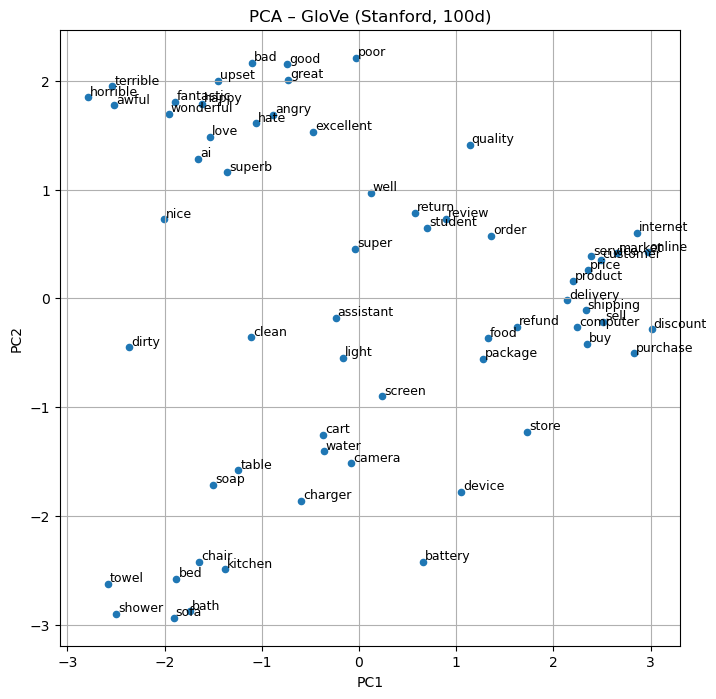

In [33]:
# === PCA for GloVe (Stanford) ===

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np


stan_vecs = []
stan_labels = []

for w in words:
    if w in model_glove:
        stan_vecs.append(model_glove[w])
        stan_labels.append(w)

stan_vecs = np.array(stan_vecs)

pca = PCA(n_components=2)
stan_reduced = pca.fit_transform(stan_vecs)

plt.figure(figsize=(8, 8))
plt.scatter(stan_reduced[:, 0], stan_reduced[:, 1], s=20)

for w, (x, y) in zip(stan_labels, stan_reduced):
    plt.text(x + 0.02, y + 0.02, w, fontsize=9)

plt.title("PCA – GloVe (Stanford, 100d)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()
